In [1]:
import geopandas as gpd

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
states = gpd.read_file("/Users/irem/Downloads/tl_2025_us_state/tl_2025_us_state.shp")

In [73]:
states.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,1,2,36,01779796,36,0400000US36,NY,New York,00,G4000,A,122049344560,19256566831,+42.9133974,-075.5962723,"MULTIPOLYGON (((-74.72623 44.99486, -74.72257 ..."
1,4,8,32,01779793,32,0400000US32,NV,Nevada,00,G4000,A,284537074263,1839852286,+39.3310928,-116.6151469,"POLYGON ((-119.32418 41.99392, -119.32362 41.9..."
2,4,9,02,01785533,02,0400000US02,AK,Alaska,00,G4000,A,1479893380150,244326118163,+63.3473560,-152.8397334,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567..."
3,9,0,60,01802701,60,0400000US60,AS,American Samoa,00,G4000,A,197759070,1307243751,-14.2668475,-170.6671854,"MULTIPOLYGON (((-168.22527 -14.53591, -168.224..."
4,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872664356,1030573104,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


<Axes: >

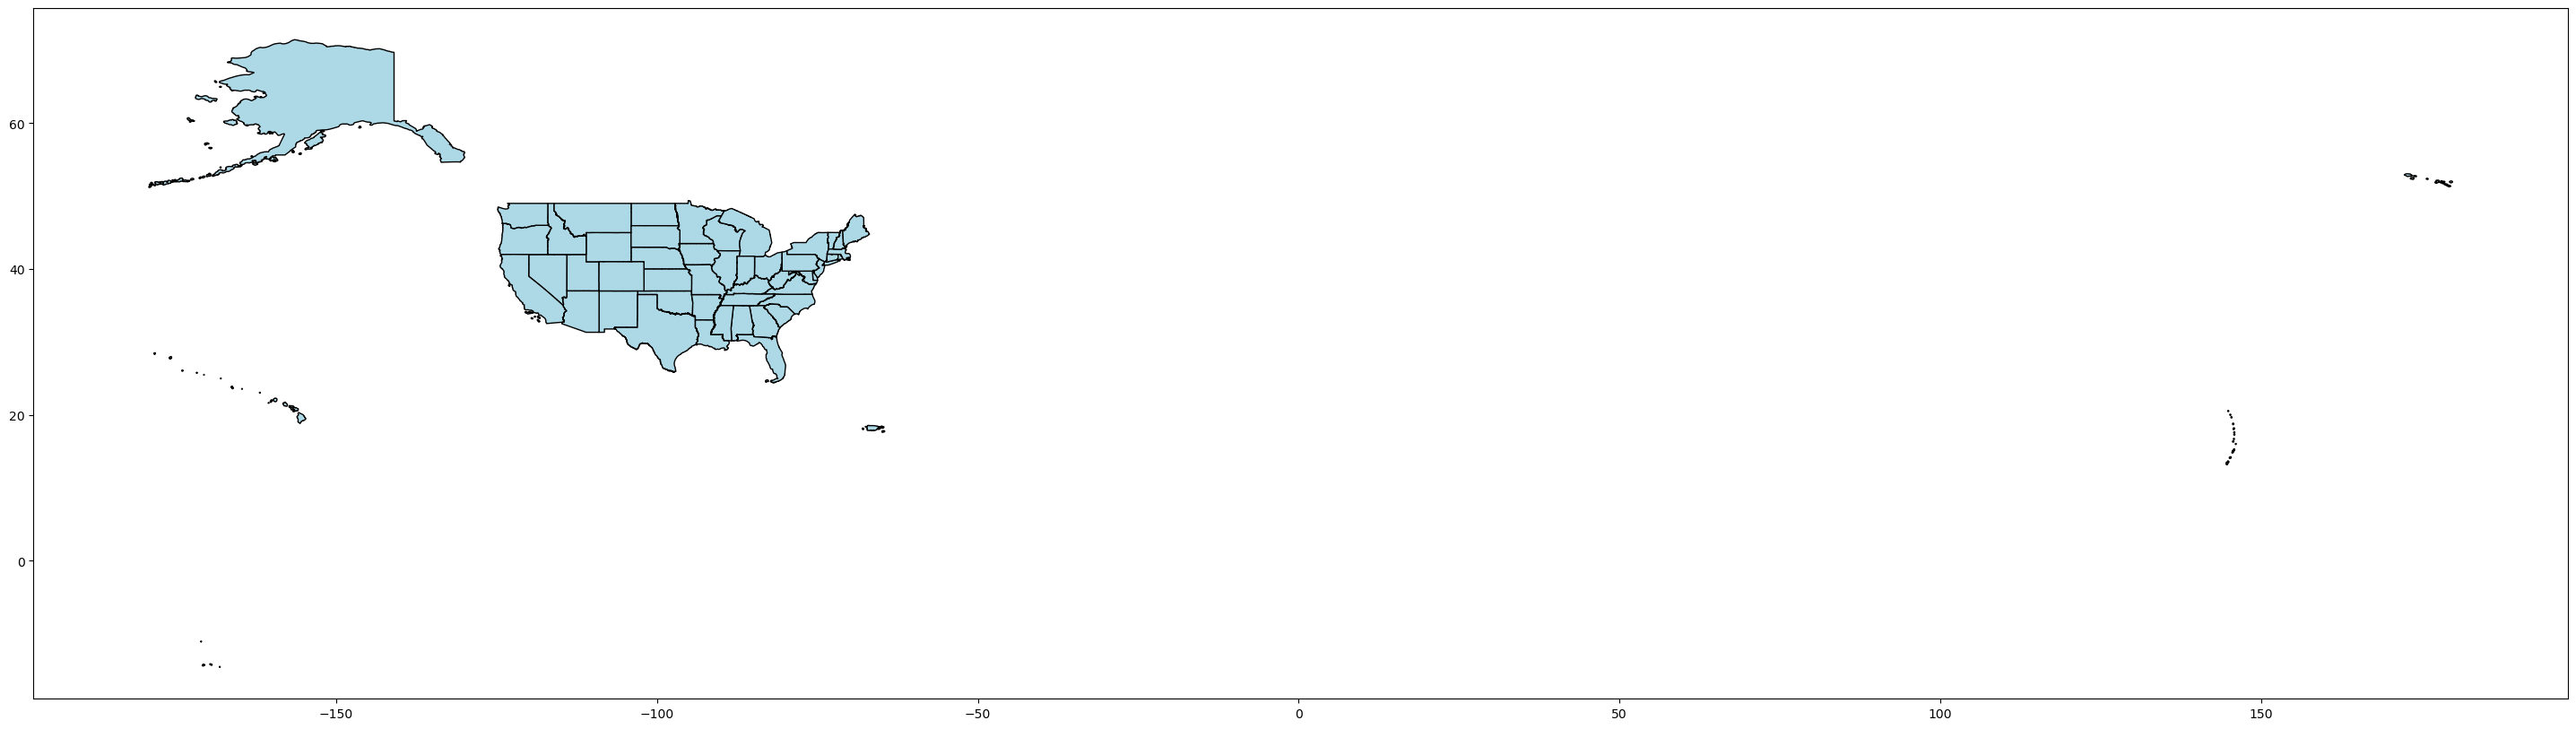

In [74]:
states.plot(figsize=(120, 10), edgecolor='black', color='lightblue')

In [75]:
population= pd.read_csv("/Users/irem/Downloads/sc-est2024-alldata6.csv")

In [76]:
population.head()

,SUMLEV,REGION,DIVISION,STATE,NAME,SEX,ORIGIN,RACE,AGE,ESTIMATESBASE2020,POPESTIMATE2020,POPESTIMATE2021,POPESTIMATE2022,POPESTIMATE2023,POPESTIMATE2024
0,40,3,6,1,Alabama,0,0,1,0,35245,35189,35613,36941,37755,37145
1,40,3,6,1,Alabama,0,0,1,1,36465,36110,35620,36060,37472,38339
2,40,3,6,1,Alabama,0,0,1,2,37748,37520,36418,36149,36659,37996
3,40,3,6,1,Alabama,0,0,1,3,38700,38377,37970,36940,36971,37398
4,40,3,6,1,Alabama,0,0,1,4,39658,39619,38786,38430,37635,37506


In [77]:
population.columns

Index(['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'SEX', 'ORIGIN',
       'RACE', 'AGE', 'ESTIMATESBASE2020', 'POPESTIMATE2020',
       'POPESTIMATE2021', 'POPESTIMATE2022', 'POPESTIMATE2023',
       'POPESTIMATE2024'],
      dtype='object')

In [48]:
black_pop = population[population['RACE'] == 2]

In [49]:
black_by_state = black_pop.groupby(['STATE', 'NAME'])['POPESTIMATE2024'].sum().reset_index()

In [50]:
black_by_state = black_by_state.rename(columns={'POPESTIMATE2024':'Black_Pop'})
print(black_by_state.head())

   STATE        NAME  Black_Pop
0      1     Alabama    5473432
1      2      Alaska     110420
2      4     Arizona    1772540
3      5    Arkansas    1921408
4      6  California   10108732


In [52]:
states['STATEFP'] = states['STATEFP'].astype(int)

In [53]:
states_merged = states.merge(black_by_state, left_on='STATEFP', right_on='STATE')

In [54]:
print(states_merged.head())

  REGION DIVISION  STATEFP   STATENS GEOID      GEOIDFQ STUSPS       NAME_x  \
0      1        2       36  01779796    36  0400000US36     NY     New York   
1      4        8       32  01779793    32  0400000US32     NV       Nevada   
2      4        9        2  01785533    02  0400000US02     AK       Alaska   
3      1        1       50  01779802    50  0400000US50     VT      Vermont   
4      1        1        9  01779780    09  0400000US09     CT  Connecticut   

  LSAD  MTFCC FUNCSTAT          ALAND        AWATER     INTPTLAT  \
0   00  G4000        A   122049344560   19256566831  +42.9133974   
1   00  G4000        A   284537074263    1839852286  +39.3310928   
2   00  G4000        A  1479893380150  244326118163  +63.3473560   
3   00  G4000        A    23872664356    1030573104  +44.0589536   
4   00  G4000        A    12542101087    1816013585  +41.5798637   

       INTPTLON                                           geometry  STATE  \
0  -075.5962723  MULTIPOLYGON (((-74.72

In [81]:
continental_states = states_merged[~states_merged['STATEFP'].isin([2,15,72,60,66,69,78])]


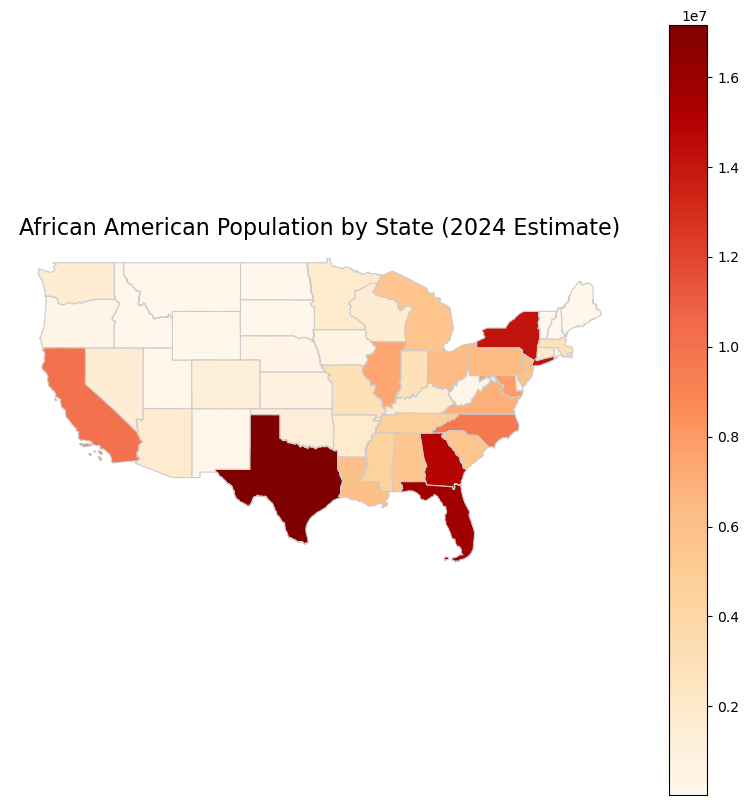

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
continental_states.plot(column='Black_Pop', cmap='OrRd', linewidth=0.8, edgecolor='0.8', legend=True, ax=ax)
ax.set_title("African American Population by State (2024 Estimate)", fontsize=16)
ax.axis('off')
plt.show()

In [ ]:
####Question 2#####
#“A spatial weights matrix formalizes the spatial relationships among states by defining 
#which units are considered neighbors and the strength of those relationships,
#allowing spatial dependence to be incorporated into statistical analysis.”

In [88]:
continental_states.geometry.head()

0    MULTIPOLYGON (((1661335.49 2631879.627, 166153...
1    POLYGON ((-1899752.494 2344539.921, -1899707.8...
3    POLYGON ((1890050.634 2591299.611, 1890055.031...
4    POLYGON ((1933885.512 2258940.671, 1932099.761...
5    POLYGON ((1728072.139 2038874.207, 1728079.162...
Name: geometry, dtype: geometry

In [134]:
continental_states.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME_x', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry', 'STATE', 'NAME_y', 'Black_Pop',
       'lag_Black_Pop'],
      dtype='object')

In [91]:
pip install pysal

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 7.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 5.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 5.8 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'spint' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'spint'. Discussion can be found at https://github.com/pypa/pip/issues/633

In [92]:
import pysal as ps

In [93]:
import libpysal

In [94]:
from libpysal.weights import Queen, Rook, KNN

In [96]:
w_knn1 = KNN.from_shapefile("/Users/irem/Downloads/tl_2025_us_state/tl_2025_us_state.shp")

/opt/anaconda3/lib/python3.13/site-packages/libpysal/io/iohandlers/pyShpIO.py:232: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices, holes)
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1405: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = list(map(Ring, vertices))
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1279: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._centroid = Point((cx, cy))
/opt/anaconda3/lib/python3.13/site-packages/libpysal/io/iohandlers/pyShpIO.py:247: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices)
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1408: FutureWarning: Ob

In [97]:
type(w_knn1)

libpysal.weights.distance.KNN

In [98]:
len(w_knn1.neighbors)

56

In [99]:
w_knn1.neighbors

{np.int64(0): [np.int64(38), np.int64(50)],
 np.int64(1): [np.int64(37), np.int64(14)],
 np.int64(2): [np.int64(51), np.int64(10)],
 np.int64(3): [np.int64(25), np.int64(37)],
 np.int64(4): [np.int64(36), np.int64(19)],
 np.int64(5): [np.int64(34), np.int64(19)],
 np.int64(6): [np.int64(33), np.int64(38)],
 np.int64(7): [np.int64(49), np.int64(23)],
 np.int64(8): [np.int64(20), np.int64(39)],
 np.int64(9): [np.int64(40), np.int64(31)],
 np.int64(10): [np.int64(51), np.int64(35)],
 np.int64(11): [np.int64(48), np.int64(45)],
 np.int64(12): [np.int64(39), np.int64(13)],
 np.int64(13): [np.int64(42), np.int64(17)],
 np.int64(14): [np.int64(1), np.int64(23)],
 np.int64(15): [np.int64(29), np.int64(46)],
 np.int64(16): [np.int64(45), np.int64(24)],
 np.int64(17): [np.int64(27), np.int64(13)],
 np.int64(18): [np.int64(49), np.int64(44)],
 np.int64(19): [np.int64(34), np.int64(5)],
 np.int64(20): [np.int64(8), np.int64(21)],
 np.int64(21): [np.int64(33), np.int64(6)],
 np.int64(22): [np.int64

In [103]:
w_queen = Queen.from_shapefile("/Users/irem/Downloads/tl_2025_us_state/tl_2025_us_state.shp")

/opt/anaconda3/lib/python3.13/site-packages/libpysal/io/iohandlers/pyShpIO.py:232: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices, holes)
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1405: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = list(map(Ring, vertices))
/opt/anaconda3/lib/python3.13/site-packages/libpysal/io/iohandlers/pyShpIO.py:247: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices)
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1408: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = [Ring(vertices)]
/opt/anaconda3/lib/python3.13/site-packages/libpysal/cg/shapes.py:1412: FutureWarning:

In [104]:
len(w_queen.neighbors)

56

In [105]:
w_queen.neighbors

{0: [34, 19, 4, 5, 38, 50],
 1: [35, 37, 23, 10, 14],
 2: [],
 3: [],
 4: [0, 19, 36],
 5: [0, 34, 19],
 6: [33, 50, 38],
 7: [16, 49, 23, 24, 14],
 8: [17, 20, 12, 39],
 9: [32, 40, 22, 31],
 10: [1, 35, 37, 51],
 11: [48, 49, 18, 22, 43, 45],
 12: [17, 39, 8, 13, 30],
 13: [17, 42, 12, 30],
 14: [1, 49, 35, 18, 23, 7],
 15: [50, 40, 27, 29, 46],
 16: [49, 7, 24, 41, 43, 45],
 17: [8, 41, 42, 43, 12, 13, 20, 27],
 18: [48, 49, 35, 11, 44, 14],
 19: [0, 34, 4, 5, 36],
 20: [33, 17, 21, 8, 27, 29],
 21: [33, 20],
 22: [32, 48, 9, 11, 43, 31],
 23: [1, 49, 37, 7, 14],
 24: [16, 41, 52, 7],
 25: [],
 26: [32, 48, 44],
 27: [17, 20, 43, 31, 29, 46, 15],
 28: [],
 29: [33, 50, 20, 27, 15],
 30: [12, 13],
 31: [22, 46, 40, 9, 27, 43],
 32: [48, 22, 40, 9, 26],
 33: [50, 20, 21, 6, 29],
 34: [0, 19, 5],
 35: [1, 18, 51, 10, 44, 14],
 36: [19, 4, 55],
 37: [1, 10, 23],
 38: [0, 50, 6],
 39: [8, 12],
 40: [32, 9, 15, 46, 31],
 41: [16, 17, 52, 24, 42, 43],
 42: [17, 52, 13, 41],
 43: [41, 11, 4

In [107]:
w_queen.neighbors[4]

[0, 19, 36]

In [110]:
wq = libpysal.weights.Queen.from_dataframe(continental_states)
wq

/var/folders/5s/rlylz0ds6dn6p6fs14w2t24h0000gn/T/ipykernel_49261/913481446.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = libpysal.weights.Queen.from_dataframe(continental_states)


In [117]:
wq.transform = 'r'

In [118]:
continental_states['lag_Black_Pop'] = (
    wq.sparse @ continental_states['Black_Pop'].values
)

In [120]:
wq.neighbors


{0: [17, 2, 3, 34, 45, 30],
 1: [33, 21, 8, 12, 31],
 2: [0, 17, 32],
 3: [0, 17, 30],
 4: [34, 29, 45],
 5: [21, 22, 44, 12, 14],
 6: [10, 18, 35, 15],
 7: [28, 27, 36, 20],
 8: [1, 31, 46, 33],
 9: [16, 20, 39, 41, 43, 44],
 10: [35, 6, 26, 11, 15],
 11: [26, 10, 38, 15],
 12: [16, 1, 5, 21, 44, 31],
 13: [36, 24, 25, 42, 45],
 14: [5, 37, 39, 22, 41, 44],
 15: [37, 6, 38, 39, 10, 11, 18, 24],
 16: [40, 9, 43, 44, 12, 31],
 17: [0, 32, 2, 3, 30],
 18: [19, 6, 24, 25, 29, 15],
 19: [18, 29],
 20: [39, 7, 9, 27, 28, 43],
 21: [1, 33, 5, 12, 44],
 22: [5, 37, 14, 47],
 23: [40, 43, 28],
 24: [18, 39, 25, 42, 27, 13, 15],
 25: [18, 45, 13, 24, 29],
 26: [10, 11],
 27: [36, 20, 7, 39, 24, 42],
 28: [20, 36, 7, 23, 43],
 29: [18, 19, 4, 25, 45],
 30: [0, 17, 3],
 31: [16, 1, 8, 40, 12, 46],
 32: [48, 17, 2],
 33: [8, 1, 21],
 34: [0, 4, 45],
 35: [10, 6],
 36: [7, 42, 27, 28, 13],
 37: [38, 39, 22, 15, 14, 47],
 38: [11, 15, 37, 47],
 39: [37, 9, 41, 14, 15, 20, 24, 27],
 40: [16, 43, 31, 

In [121]:
wq.weights

{0: [0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666],
 1: [0.2, 0.2, 0.2, 0.2, 0.2],
 2: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 3: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 4: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
 5: [0.2, 0.2, 0.2, 0.2, 0.2],
 6: [0.25, 0.25, 0.25, 0.25],
 7: [0.25, 0.25, 0.25, 0.25],
 8: [0.25, 0.25, 0.25, 0.25],
 9: [0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666],
 10: [0.2, 0.2, 0.2, 0.2, 0.2],
 11: [0.25, 0.25, 0.25, 0.25],
 12: [0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666],
 13: [0.2, 0.2, 0.2, 0.2, 0.2],
 14: [0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666666666666666,
  0.16666

In [123]:
W, ids = wq.full()

In [124]:
W[:5, :5]

array([[0.        , 0.        , 0.16666667, 0.16666667, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.33333333, 0.        , 0.        , 0.        , 0.        ],
       [0.33333333, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [ ]:
####Above we see the matrix, wq.neighbors shows the neighbors of states, 2 is neighbor with 0, 17 and 32. 

In [136]:
continental_states[['STATE', 'NAME_y']].reset_index(drop=True).loc[[0, 2, 17, 32]]

,STATE,NAME_y
0,36,New York
2,50,Vermont
17,25,Massachusetts
32,33,New Hampshire


In [ ]:
#So, Vermont's neighboring states are New York, Massachusetts and New Hampshire. 

In [ ]:
#######Question 3#########

In [ ]:
#So, Moran I's basically describes spatial autocorrelation, whether neighboring states have similar characteristics. 
#In the case of my merged_data, it will describe whether neighboring states have similar african-american population rates. 
#So, we can see whether states with large african-american population is clustered together. 

In [138]:
from esda.moran import Moran

In [139]:
mi_black = Moran(continental_states['Black_Pop'], wq)

In [142]:
mi_black.I

np.float64(0.2517120449425282)

In [ ]:
#0.25 is defined as solidly moderate. Thus, indicated regional clustering, 
#thus states with similar proportions of african american population tend to locate each other in clusters more than being random.
#If it was>0.30 then we would have said it is a strong regional clustering. 

In [141]:
mi_black.p_sim

np.float64(0.007)

In [ ]:
#p_value is >0.05 thus above result is statistically significant. 

In [ ]:
#######Question 4###########

In [143]:
import spreg

In [151]:
y= continental_states['Black_Pop'].values

In [152]:
x_OLS = continental_states[['lag_Black_Pop']].values
x_OLS


array([[ 2945332.        ],
       [ 2528356.8       ],
       [ 5697822.66666667],
       [ 5798514.66666667],
       [ 6771225.33333333],
       [ 4331091.2       ],
       [ 8058620.        ],
       [ 3905210.        ],
       [ 3290441.        ],
       [  933135.33333333],
       [ 8270140.        ],
       [ 9950640.        ],
       [  793868.        ],
       [ 3408463.2       ],
       [ 4030084.        ],
       [ 5995038.        ],
       [  350134.66666667],
       [ 3337441.6       ],
       [ 4248174.        ],
       [ 7472768.        ],
       [ 2397065.33333333],
       [ 2645115.2       ],
       [ 2365436.        ],
       [  678224.        ],
       [ 4538867.42857143],
       [ 5901348.        ],
       [10144426.        ],
       [ 2571916.        ],
       [ 1628997.6       ],
       [ 3205600.        ],
       [ 6311177.33333333],
       [  616024.66666667],
       [ 1006797.33333333],
       [ 1214834.66666667],
       [ 7210966.66666667],
       [12257772.   

In [153]:
continental_states['lag_Black_Pop'].values

array([ 2945332.        ,  2528356.8       ,  5697822.66666667,
        5798514.66666667,  6771225.33333333,  4331091.2       ,
        8058620.        ,  3905210.        ,  3290441.        ,
         933135.33333333,  8270140.        ,  9950640.        ,
         793868.        ,  3408463.2       ,  4030084.        ,
        5995038.        ,   350134.66666667,  3337441.6       ,
        4248174.        ,  7472768.        ,  2397065.33333333,
        2645115.2       ,  2365436.        ,   678224.        ,
        4538867.42857143,  5901348.        , 10144426.        ,
        2571916.        ,  1628997.6       ,  3205600.        ,
        6311177.33333333,   616024.66666667,  1006797.33333333,
        1214834.66666667,  7210966.66666667, 12257772.        ,
        4056226.4       ,  6094986.66666667,  4534043.        ,
        2352422.5       ,    85860.        ,  1468022.        ,
        5295285.        ,   527800.        ,   684682.85714286,
        5951164.66666667,   258596.     

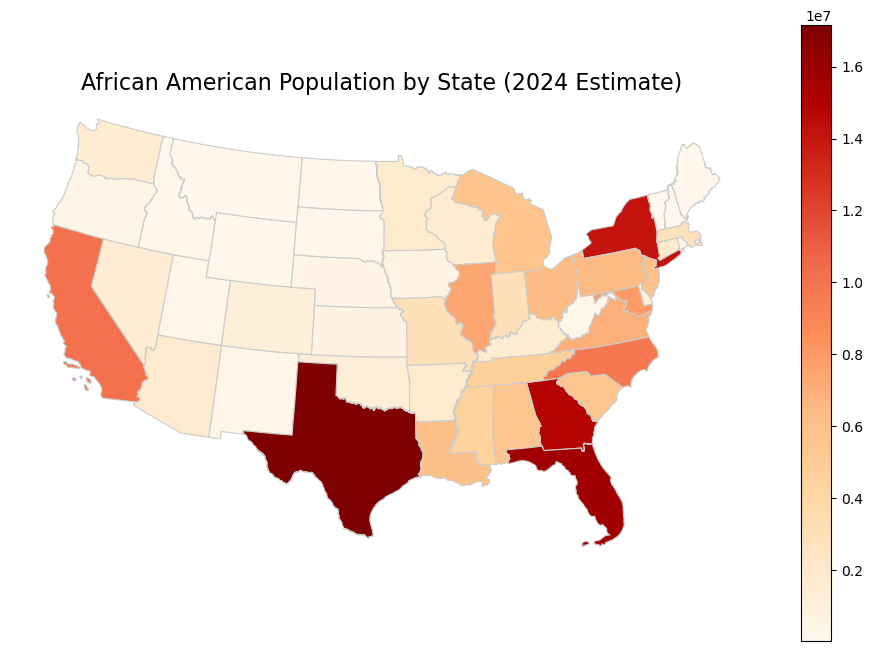

In [156]:
###this is the same plot with the one at the beginning of the page

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
continental_states.plot(column='Black_Pop', cmap='OrRd', linewidth=0.8, edgecolor='0.8', legend=True, ax=ax)
ax.set_title("African American Population by State (2024 Estimate)", fontsize=16)
ax.axis('off')
plt.show()


In [ ]:
#We see in the south there is a cluster of states with relatively higher african american population
#which is also a sociologically and historically valid argument. 